# Knights of Spamalot — One-Class SVM (UCI SMS Spam Collection)
**Independent experiment for Module #7.** This notebook downloads the publicly available SMS dataset and does not change your team's existing notebooks.

**Run instructions:** Open in Google Colab → Runtime → Run all. It requires internet access in Colab. The evaluation uses a held-out stratified test split. Only **ham training messages** are used to fit the text feature extractor and One-Class SVM. Labels are used to create the split and score the test set, not to train the anomaly detector.

**Important:** This experiment uses SMS text messages, not the Spambase numerical email dataset or your teammates' `email_data.csv`. Cross-model comparisons are not controlled unless the other models are rerun on the same held-out split.

In [1]:
import io, zipfile, urllib.request
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.svm import OneClassSVM
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

DATA_URL = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'
with urllib.request.urlopen(DATA_URL, timeout=60) as response:
    archive_bytes = response.read()

def extract_sms_bytes(raw):
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        for name in z.namelist():
            if name.split('/')[-1] == 'SMSSpamCollection':
                return z.read(name)
        for name in z.namelist():
            if name.lower().endswith('.zip'):
                try:
                    return extract_sms_bytes(z.read(name))
                except (ValueError, zipfile.BadZipFile):
                    pass
    raise ValueError('SMSSpamCollection text file not found in UCI archive.')

sms = pd.read_csv(io.BytesIO(extract_sms_bytes(archive_bytes)), sep='\t',
                  names=['label', 'message'], encoding='latin-1')
sms = sms.dropna(subset=['label','message']).copy()
sms = sms[sms['label'].isin(['ham','spam'])]
sms['is_spam'] = (sms['label'] == 'spam').astype(int)
print('Dataset size:', len(sms))
print(sms['label'].value_counts())

Dataset size: 5572
label
ham     4825
spam     747
Name: count, dtype: int64


## Split the data and train on legitimate messages only

`random_state=42` makes the experiment reproducible. We use a stratified 80/20 split, then fit TF-IDF and dimensionality reduction **only on ham training messages** to avoid test-set leakage. `nu=0.10` is an initial setting, not a tuned optimum.

In [2]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    sms['message'], sms['is_spam'], test_size=0.20,
    stratify=sms['is_spam'], random_state=42
)
ham_train_text = X_train_text[y_train == 0]

oc_tfidf = TfidfVectorizer(lowercase=True, stop_words='english',
                           ngram_range=(1, 2), max_features=2500, min_df=2)
X_ham_tfidf = oc_tfidf.fit_transform(ham_train_text)
X_test_tfidf = oc_tfidf.transform(X_test_text)

n_components = min(100, X_ham_tfidf.shape[0]-1, X_ham_tfidf.shape[1]-1)
oc_svd = TruncatedSVD(n_components=n_components, random_state=42)
X_ham_svd = oc_svd.fit_transform(X_ham_tfidf)
X_test_svd = oc_svd.transform(X_test_tfidf)
oc_norm = Normalizer()
X_ham = oc_norm.fit_transform(X_ham_svd)
X_test = oc_norm.transform(X_test_svd)

oc_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.10)
oc_model.fit(X_ham)

# scikit-learn returns +1 for inliers (ham), -1 for outliers (potential spam)
y_pred = (oc_model.predict(X_test) == -1).astype(int)
# Lower decision_function values mean more anomalous, so negate for spam ROC-AUC.
spam_scores = -oc_model.decision_function(X_test)

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision_spam': precision_score(y_test, y_pred, zero_division=0),
    'recall_spam': recall_score(y_test, y_pred, zero_division=0),
    'f1_spam': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc_spam': roc_auc_score(y_test, spam_scores),
}
print('One-Class SVM metrics on held-out SMS messages:')
for key, value in metrics.items():
    print(f'{key}: {value:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['ham', 'spam'], zero_division=0))
print('Confusion matrix (rows = actual ham/spam, columns = predicted ham/spam):')
print(confusion_matrix(y_test, y_pred, labels=[0,1]))

One-Class SVM metrics on held-out SMS messages:
accuracy: 0.7614
precision_spam: 0.0791
recall_spam: 0.0738
f1_spam: 0.0764
roc_auc_spam: 0.3923

Classification report:
              precision    recall  f1-score   support

         ham       0.86      0.87      0.86       966
        spam       0.08      0.07      0.08       149

    accuracy                           0.76      1115
   macro avg       0.47      0.47      0.47      1115
weighted avg       0.75      0.76      0.76      1115

Confusion matrix (rows = actual ham/spam, columns = predicted ham/spam):
[[838 128]
 [138  11]]


## Visuals for Section 6: Analysis & Results

The confusion matrix and metrics chart can be inserted into your paper and slides. Use the actual numbers printed above; do not invent scores.

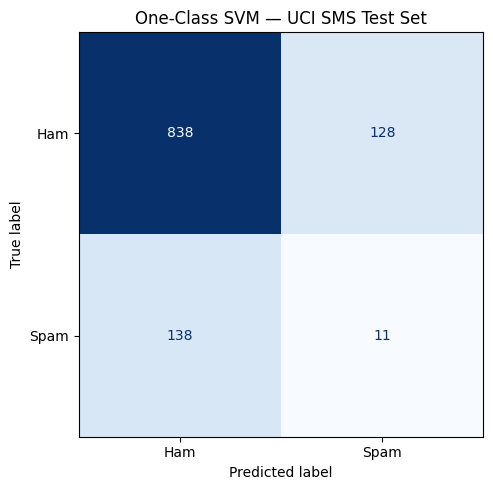

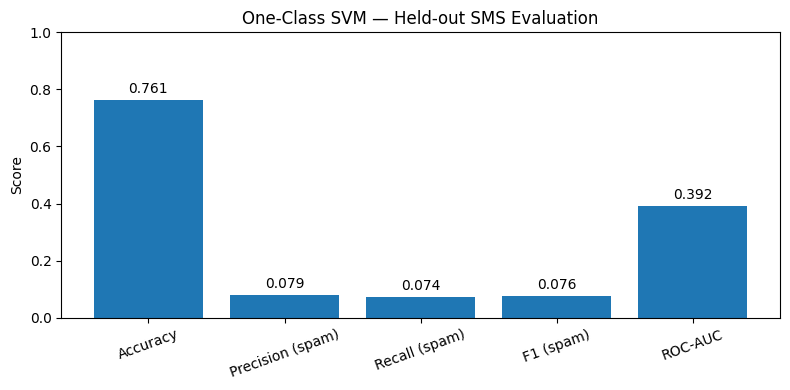

Saved: one_class_svm_confusion_matrix.png, one_class_svm_metrics.png, one_class_svm_results.csv


In [3]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('One-Class SVM — UCI SMS Test Set')
fig.tight_layout()
fig.savefig('one_class_svm_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
metric_names = ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1 (spam)', 'ROC-AUC']
values = list(metrics.values())
ax.bar(metric_names, values)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('One-Class SVM — Held-out SMS Evaluation')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(values):
    ax.text(i, min(v + 0.025, 0.98), f'{v:.3f}', ha='center')
fig.tight_layout()
fig.savefig('one_class_svm_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

pd.DataFrame([{'model': 'One-Class SVM', 'dataset': 'UCI SMS Spam Collection',
               'test_messages': len(y_test), **metrics}]).to_csv('one_class_svm_results.csv', index=False)
print('Saved: one_class_svm_confusion_matrix.png, one_class_svm_metrics.png, one_class_svm_results.csv')